# `Customer Churn Analysis`
by Husna khanam

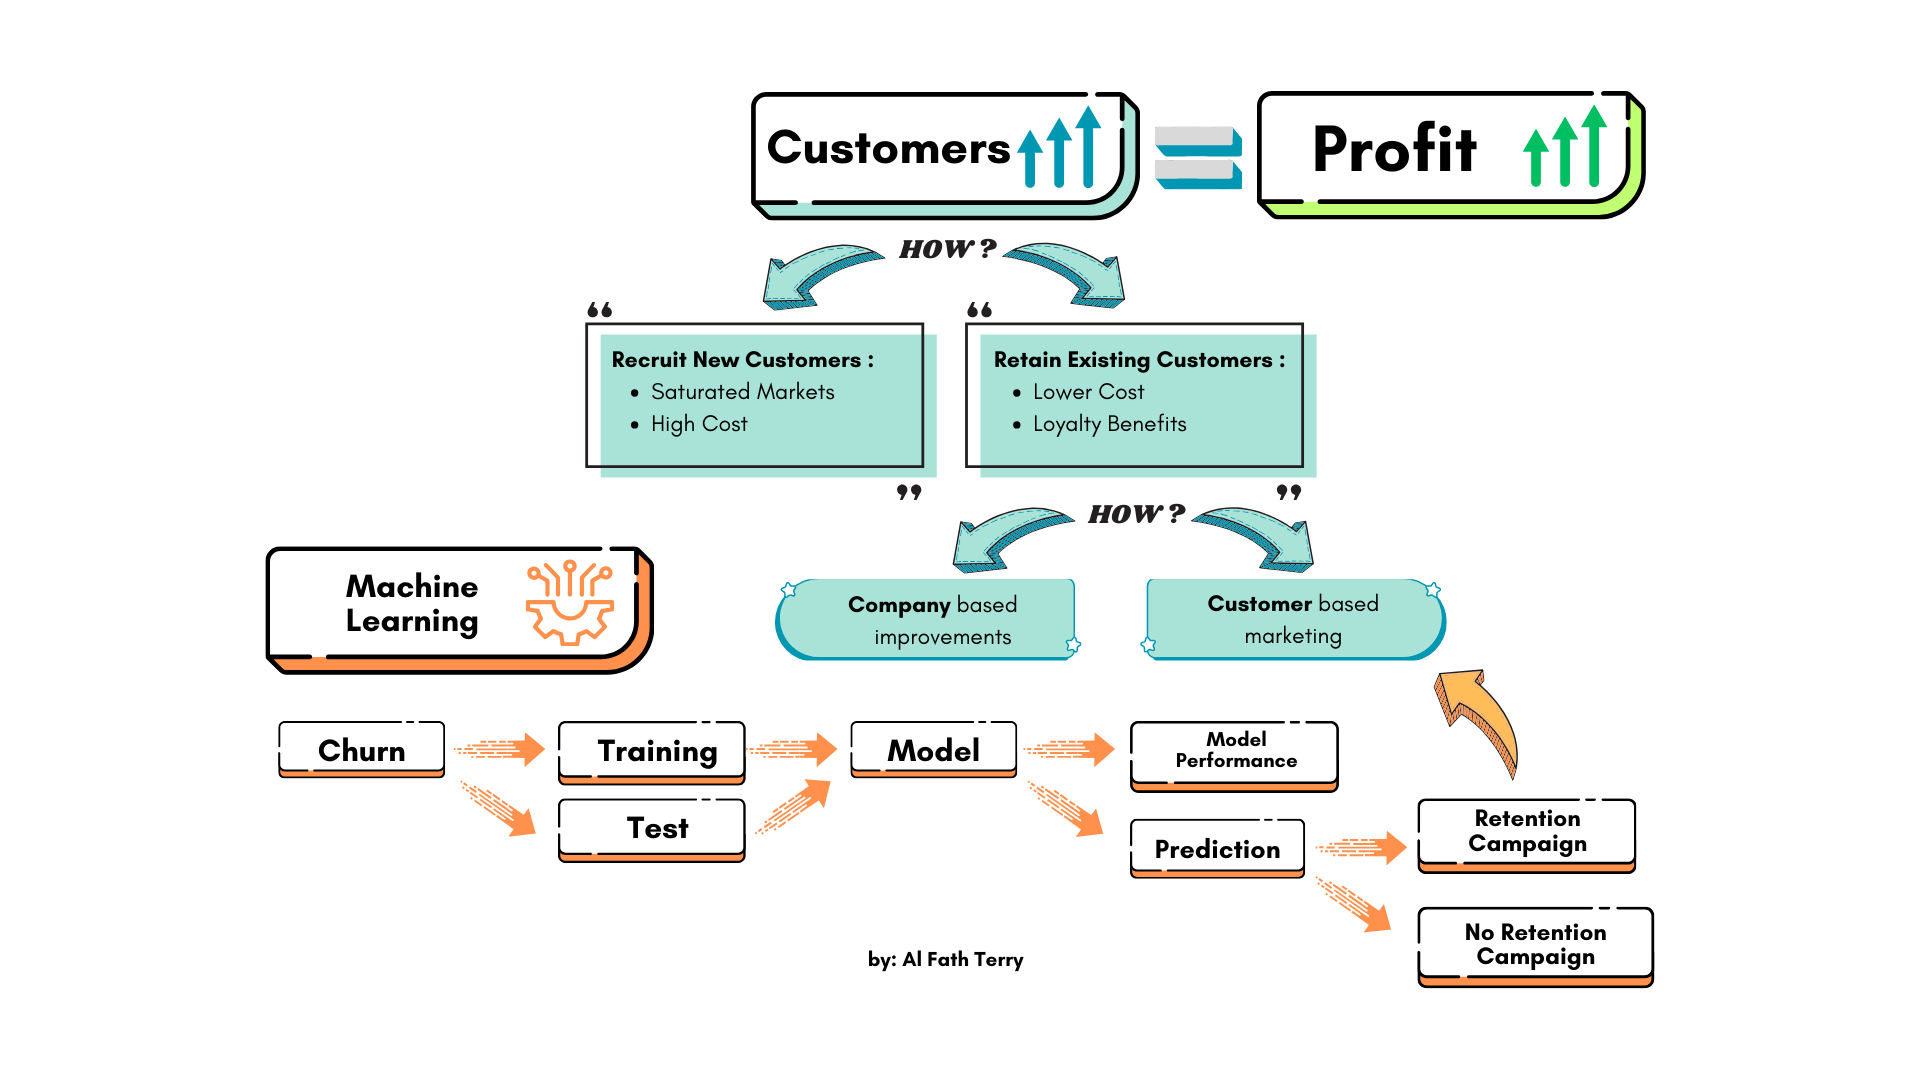

---

## `Source`
- [Dataset]('https://www.kaggle.com/datasets/sonalshinde123/customer-churn-prediction-dataset')

---

## `Business Problem`
We are losing customers and money. Every time a customer leaves, it costs us significantly more to replace them with a new one. Right now, we do not know exactly who is about to leave, why they are unhappy, or how much cash we are losing because of it.
## `Project Goal`
We will use data to predict and stop customer loss before it happens. This analysis will answer three critical questions for leadership:

   
   1. Why are they leaving? (Is it high prices, bad support, or contracts?)
   2. How much money will the company lose if we do nothing?




---

The [Customer Churn Dataset by Sonal Shinde on Kaggle](https://www.kaggle.com/datasets/sonalshinde123/customer-churn-prediction-dataset) is a synthetic telecom dataset containing 20,000 customer records designed for binary classification tasks. The primary keywords (column headers/features) present in this dataset and their functional meanings include:

* customer_id: A unique alphanumeric code assigned to distinguish each individual customer account.
  
* tenure: The total number of months the customer has continuously stayed active with the telecom provider.
  
* contract: The terms of the billing agreement, typically split into "Month-to-month", "One year", or "Two year" options. 
  
* monthly_charges: The specific recurring dollar amount billed to the customer each month.
  
* total_charges: The cumulative financial amount billed over the customer's entire account lifespan, mathematically represented as tenure × monthly_charges.
  
* payment_method: The transactional medium used by the customer to pay bills, such as electronic checks, credit cards, or bank transfers.
   
* internet_service: The specific infrastructure technology subscribed to by the user, such as DSL, Fiber optic, or none.
  
* online_security: A yes/no flag indicating if the customer has an active subscription to web-browsing security add-ons.
  
* tech_support: A yes/no flag showing whether the account includes prioritized technical customer support services.
  
* support_calls: A numerical counter tracking how many times the customer contacted customer assistance regarding service issues. 
   
* churn: The primary binary prediction metric (typically labeled 1 for left/canceled and 0 for stayed/active) used to evaluate machine learning models. 



---

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.pipeline import Pipeline


Matplotlib is building the font cache; this may take a moment.


- # DATA CHECK

This is where you understand the scale and health of your data before doing any deep work

In [3]:
#loading the dataset
df = pd.read_csv(r'C:\Users\Admin\Downloads\My_work\customer_churn\customer_churn_dataset.csv')
# displaying the first 5 rows of the dataset
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [4]:
#  shape tells us the the number of rows and columns in the dataset. It returns a tuple with the number of rows and columns.
df.shape

(20000, 11)

In [5]:
#  It gives you a quick snapshot of your data's size, column names, missing values, and data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  str    
 5   payment_method    20000 non-null  str    
 6   internet_service  17987 non-null  str    
 7   tech_support      20000 non-null  str    
 8   online_security   20000 non-null  str    
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 2.2 MB


In [6]:
# it shows the number of missing values in each column of the DataFrame.
df.isnull().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

- # EXPLORATORY DATA ANALYSIS

This is where you discover patterns and understand relationship between features

<Axes: xlabel='tenure', ylabel='Count'>

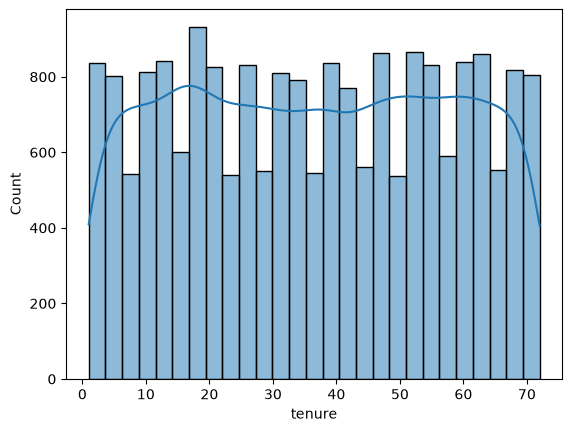

In [7]:
sns.histplot(df['tenure'],kde=True )

INTERPRETATION:

* Even Spread: Customers are distributed almost perfectly evenly across all tenure lengths (from 1 month to 72 months).
* No Sudden Drops: There is no specific month where a massive group of customers suddenly leaves or cuts ties all at once.



<Axes: xlabel='total_charges', ylabel='Count'>

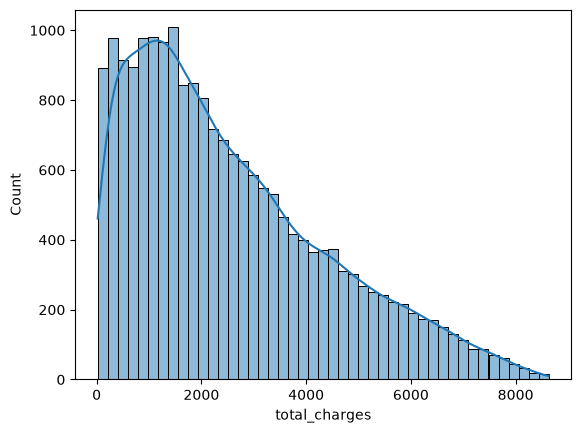

In [8]:
sns.histplot(df['total_charges'],kde=True)

INTERPRETATION :
- The graph shows a right-skewed pattern  
- The majority of accounts have low-to-moderate total charges (under 2,000), while only a few long-term or high-tier customers reach total charges above 6,000.

<Axes: xlabel='contract', ylabel='Count'>

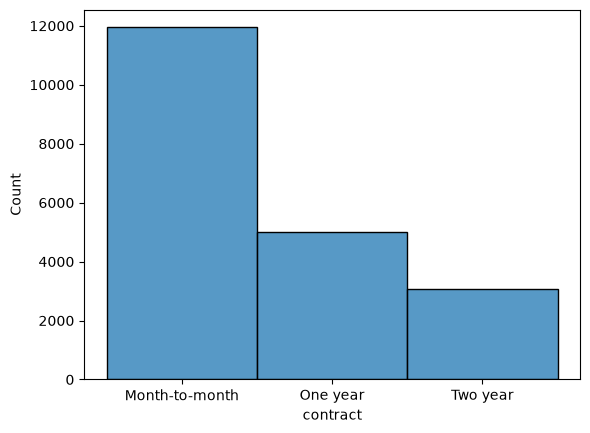

In [9]:
sns.histplot(df['contract'])

INTERPRETATION : 
- The graph shows a right-skewed pattern  
- The majority of accounts have month-to-month contract , while only a few long-term or high-tier customers reach one year or two year contract.

<Axes: xlabel='payment_method', ylabel='Count'>

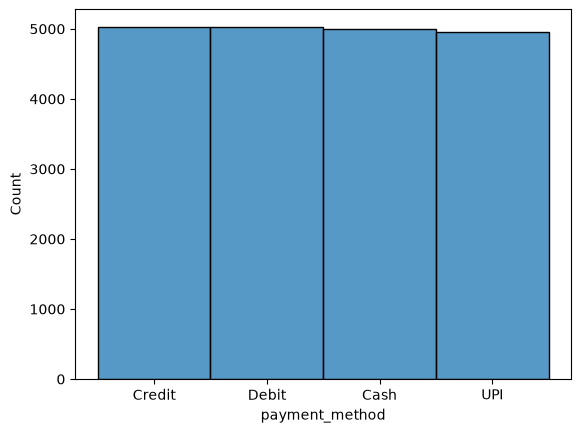

In [10]:
sns.histplot(df['payment_method'])

INTERPRETATION:

* Equal Distribution: Customers are split almost perfectly evenly across all four payment choices.
* No Favorite Method: Credit, Debit, Cash, and UPI are equally popular, with about 5,000 users each.



<Axes: xlabel='internet_service', ylabel='Count'>

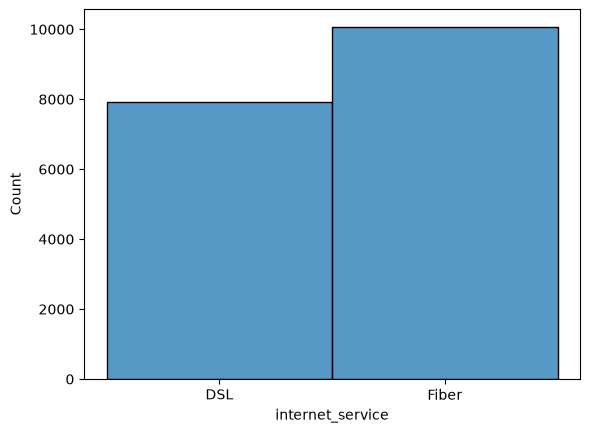

In [11]:
sns.histplot(df['internet_service'])

INTERPRETATION:
* Fiber is Preferred: Fiber optic is the more popular choice among customers, with around 10,000 users.
* Significant DSL Share: DSL is still widely used, trailing slightly behind at roughly 8,000 users.

<Axes: xlabel='tech_support', ylabel='Count'>

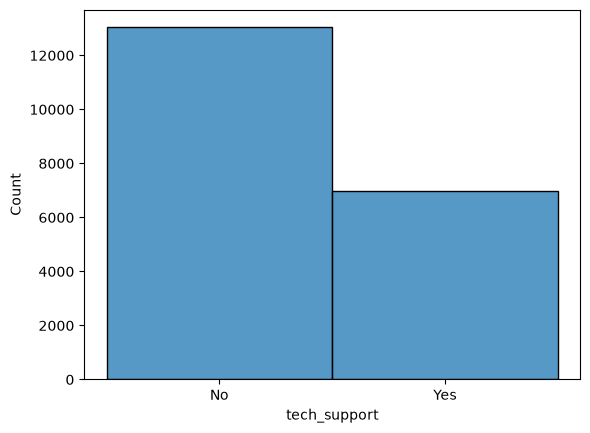

In [12]:
sns.histplot(df['tech_support'])

INTERPRETATION :
* Low Adoption: A vast majority of customers (around 13,000) do not use tech support services.
* Minority Usage: Less than half of the user base (roughly 7,000) have tech support enabled on their accounts.

<Axes: xlabel='online_security', ylabel='Count'>

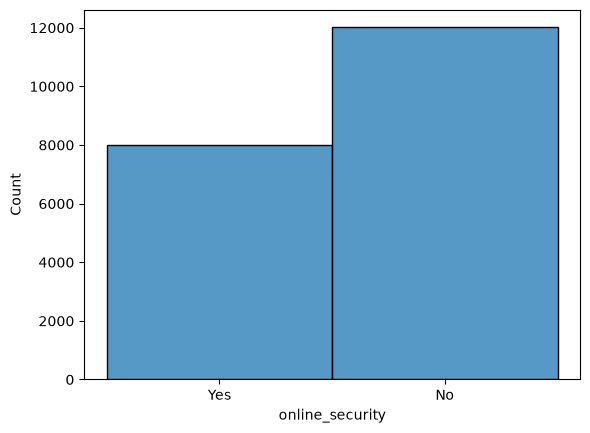

In [13]:
sns.histplot(df['online_security'])

INTERPRETATION :
* Low Adoption: A vast majority of customers (around 12,000) do not use online security services.
* Minority Usage: Less than half of the user base (roughly 8,000) have online security services enabled on their accounts.

<Axes: xlabel='support_calls', ylabel='Count'>

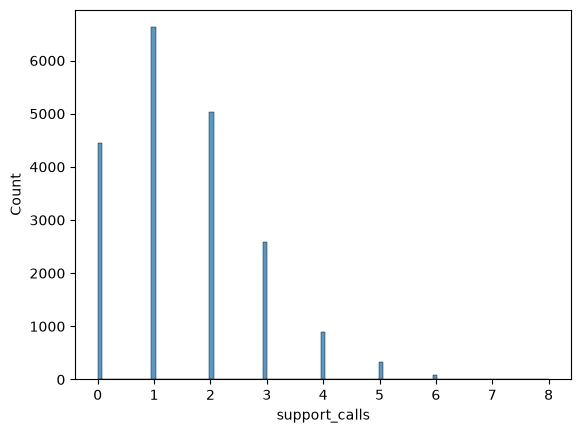

In [14]:
sns.histplot(df['support_calls'])

INTERPRETATION :
* Right-Skewed Distribution: The data peaks sharply at 1 call and drops off rapidly, showing that very few customers make 4 or more support calls.
* Low Volume Dominates: The vast majority of customers require minimal assistance, typically making between 0 to 2 support calls.

<Axes: xlabel='churn', ylabel='Count'>

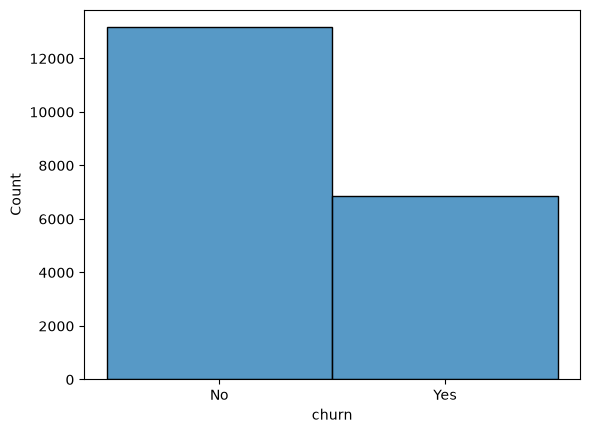

In [15]:
sns.histplot(df['churn'])

INTERPRETATION :
* Most Customers Stay: About 13,000 customers decided to stay with the company.
* Big Loss: Around 7,000 customers left, highlighting a major retention problem that requires intervention.

<Axes: xlabel='tenure', ylabel='total_charges'>

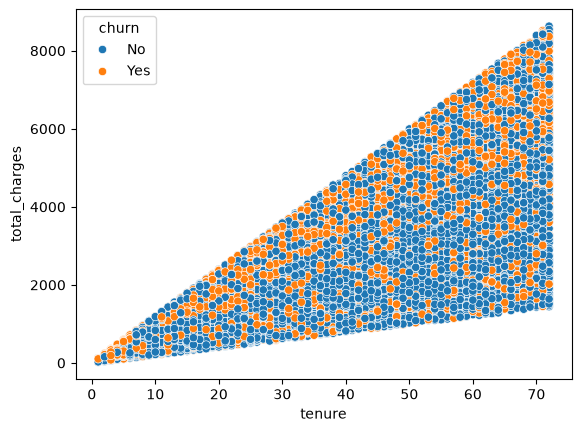

In [16]:
sns.scatterplot(x='tenure',y='total_charges',data=df,hue='churn')

INTERPRETATION :
* Longer Time Means Higher Bills: The more months a customer stays (tenure), the more total money they spend. 
* No Clear Churn Pattern: The orange dots (people who left) and blue dots (people who stayed) are completely mixed together everywhere. This means you cannot guess if a customer will leave just by looking at their total bills and months.

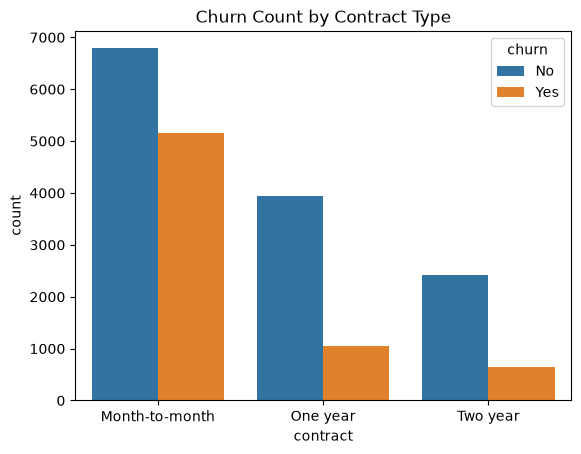

In [17]:
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn Count by Contract Type")
plt.show()


INTERPRETATION :
* Month-to-Month is High Risk: Most of the people who leave (orange bars) are on Month-to-month contracts. Over 5,000 customers left from this group alone.
* Long Contracts Keep Customers: One-year and Two-year contracts have very small orange bars, meaning long-term agreements successfully prevent customer loss.

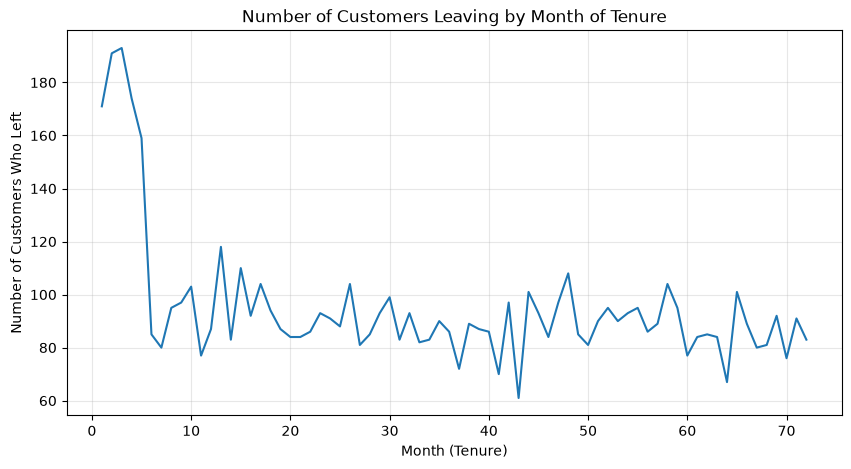

In [18]:


# 1. Filter data to look ONLY at customers who left (churn == 'Yes')
left_customers = df[df['churn'] == 'Yes']

# 2. Count how many people left in each specific month
churn_counts_by_month = left_customers['tenure'].value_counts().sort_index()

# 3. Plot a clean trend line
plt.figure(figsize=(10, 5))
sns.lineplot(x=churn_counts_by_month.index, y=churn_counts_by_month.values)

plt.title("Number of Customers Leaving by Month of Tenure")
plt.xlabel("Month (Tenure)")
plt.ylabel("Number of Customers Who Left")
plt.grid(True, alpha=0.3)
plt.show()


INTERPRETATION :
* High Early Risk: Customer loss peaks dramatically in the first 5 months, showing that new users are the most likely to leave the company. 
* Stable Long-Term Trend: After month 6, customer loss drops significantly and stabilizes, hovering mostly between 80 to 100 departures per month.

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  str    
 5   payment_method    20000 non-null  str    
 6   internet_service  17987 non-null  str    
 7   tech_support      20000 non-null  str    
 8   online_security   20000 non-null  str    
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 2.2 MB


In [20]:
# 1. Separate features and target (Full Dataset)
x = df.drop('churn', axis=1)
y = df['churn']

# 2. Split the RAW data first (This prevents data leakage)
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

# 3. Define feature groups
numeric_features = ['tenure', 'monthly_charges', 'total_charges' , 'support_calls']
categorical_features = [ 'internet_service', 'online_security',  'tech_support', 'contract', 'payment_method']

# 4. Create transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

# 5. Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Build the complete Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())])

# 7. Train the pipeline (It automatically handles fit_transform on x_train safely)
model.fit(x_train , y_train)

# 8. Predict and Evaluate using the hidden test set
y_pred = model.predict(x_test)


classification_rep = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label='Yes')
precision = precision_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print(f'Classification Report:{classification_rep}')
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print(f'F1-Score: {f1}')






c:\Users\Admin\miniconda3\envs\streamlit_env\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Classification Report:              precision    recall  f1-score   support

          No       0.80      0.91      0.85      2645
         Yes       0.76      0.55      0.64      1355

    accuracy                           0.79      4000
   macro avg       0.78      0.73      0.75      4000
weighted avg       0.79      0.79      0.78      4000

Accuracy: 0.7905
Recall: 0.5549815498154982
Precision: 0.7619047619047619
F1-Score: 0.6421861656703672


`EVALUATION CONCLUSION`
- The model is highly reliable when it alerts us about a customer leaving (76% Precision) and performs well overall with a 79% accuracy rate. However, its main weakness is that it misses nearly half of the customers who are actually planning to leave (only 55% Recall).

In [23]:
# Get feature names after one-hot encoding
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients
coefficients = model.named_steps['classifier'].coef_[0]

# Create a dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by impact
importance_df = importance_df.sort_values('Coefficient', ascending=False)

print(importance_df)

                         Feature  Coefficient
11  cat__contract_Month-to-month     0.668526
1           num__monthly_charges     0.567235
3             num__support_calls     0.491324
9           cat__tech_support_No     0.371012
2             num__total_charges     0.131194
14      cat__payment_method_Cash    -0.103098
16     cat__payment_method_Debit    -0.108964
15    cat__payment_method_Credit    -0.121051
17       cat__payment_method_UPI    -0.123349
6      cat__internet_service_nan    -0.145098
5    cat__internet_service_Fiber    -0.150518
4      cat__internet_service_DSL    -0.160847
8       cat__online_security_Yes    -0.207883
7        cat__online_security_No    -0.248579
0                    num__tenure    -0.321374
13        cat__contract_Two year    -0.540680
12        cat__contract_One year    -0.584308
10         cat__tech_support_Yes    -0.827474


## Model Interpretation: Key Factors Influencing Customer Churn

To understand which factors contribute most to customer churn, the coefficients of the Logistic Regression model were analyzed.

### Factors Increasing Churn Risk

* **Month-to-Month Contract (+0.669):** Customers on month-to-month plans are more likely to churn compared to customers on long-term contracts.
* **Monthly Charges (+0.567):** Higher monthly charges are associated with a higher probability of churn.
* **Support Calls (+0.491):** Customers who contact support more frequently are more likely to leave, suggesting dissatisfaction or unresolved issues.
* **No Tech Support (+0.371):** Customers without technical support services show a higher tendency to churn.

### Factors Reducing Churn Risk

* **Tech Support Subscription (-0.827):** Customers with tech support are significantly less likely to churn.
* **One-Year Contract (-0.584):** Long-term contracts improve customer retention.
* **Two-Year Contract (-0.541):** Customers on two-year contracts are less likely to leave.
* **Customer Tenure (-0.321):** Customers who have stayed with the company for a longer period tend to be more loyal.
* **Online Security Service (-0.208):** Customers using online security services show lower churn rates.

### Business Recommendations

Based on these findings, the company can reduce churn by:

1. Encouraging customers to switch from month-to-month plans to long-term contracts.
2. Improving customer support quality and reducing repeated support calls.
3. Promoting technical support and online security services.
4. Offering retention incentives to customers with high monthly charges.

### Conclusion

Contract type, monthly charges, support calls, and tech support services were identified as the most influential factors affecting customer churn. These insights can help the business design targeted retention strategies and improve customer satisfaction.

If no action is taken, the company risks losing approximately $546165.69 in monthly recurring revenue from churned customers.

A churn rate of 34.22% indicates substantial customer attrition. Reducing churn even by a small percentage could lead to meaningful improvements in customer retention, recurring revenue, and overall business profitability.

In [24]:
#How much money will the company lose if we do nothing?
churned_customers = df[df['churn'] == 'Yes']

monthly_revenue_lost = churned_customers['monthly_charges'].sum()

print(monthly_revenue_lost)

546165.69


In [25]:
#How many customers are going to leave?
churn_count = (df['churn'] == 'Yes').sum()
total_customers = len(df)

churn_percentage = (churn_count / total_customers) * 100

print(f"Churned Customers: {churn_count}")
print(f"Churn Rate: {churn_percentage:.2f}%")

Churned Customers: 6843
Churn Rate: 34.22%


In [21]:
# saving the model
import joblib

model_filename = 'customer_churn_model.joblib'

# Force save your updated 'model' pipeline variable
joblib.dump(model, r'c:\Users\Admin\Downloads\My_work\customer_churn\notebook\customer_churn_model.joblib')
print("✅ File successfully saved with the new version!")


✅ File successfully saved with the new version!
